# ENTREGA 4 — Análise Crítica Individual do Modelo Campeão

**Aluno:** Paulo Henrique dos Santos Tristão &nbsp;|&nbsp; RA: 082210017  
**Grupo:** Guilherme G. Garcia · Lohan B. Moreira · Paulo H. S. Tristão · Rodrigo P. Matioli  
**Projeto:** Previsão de *No-show* em Consultas Médicas (`no_show_flag`)  
**Modelo Campeão (ENTREGA 3):** `GradientBoostingClassifier` (scikit-learn)

## Objetivo desta entrega
Esta é uma **cópia simplificada** do notebook do grupo, focada exclusivamente nas tarefas individuais da ENTREGA 4:

1. **Tuning de hiperparâmetros** — alterar ≥ 3 hiperparâmetros do Gradient Boosting e medir o impacto.
2. **Análise de impacto** — comparar *Modelo Original do Grupo* vs *Modelo Otimizado* em métrica e tempo de execução.
3. **Teste de estresse (diferencial)** — remover a variável considerada mais importante na ENTREGA 2 (`previous_no_shows`) e medir a queda de performance.

A métrica principal adotada é a **ROC-AUC**, alinhada ao critério de escolha do modelo campeão no README do grupo.

> **Nota:** Esta análise explora uma estratégia de tuning diferente da adotada por outros integrantes: em vez de reduzir a taxa de aprendizado e aumentar a profundidade, optei por **acelerar o aprendizado** com `learning_rate` maior e introduzir **aleatoriedade controlada** via `subsample`, uma técnica chamada *Stochastic Gradient Boosting*.

## 1. Imports e carga dos dados

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

In [6]:
# Download do dataset (mesma fonte do notebook do grupo)
import kagglehub
path = kagglehub.dataset_download("jayjoshi37/healthcare-no-show-and-wait-time-analysis")
df = pd.read_csv(str(path) + '/healthcare_appointment_no_show_wait_time.csv')
print('Shape:', df.shape)
df.head()

Shape: (2800, 11)


,appointment_id,appointment_date,patient_age,gender,department,appointment_type,scheduled_hour,waiting_time_minutes,reminder_sent,previous_no_shows,appointment_status
0,1,2024-01-01 00:00:00,52,Female,Orthopedics,New,12,82,Yes,4,Completed
1,2,2024-01-01 01:00:00,15,Female,Cardiology,Follow-up,9,176,No,2,No-Show
2,3,2024-01-01 02:00:00,72,Female,Orthopedics,New,13,100,Yes,2,Completed
3,4,2024-01-01 03:00:00,61,Female,Orthopedics,New,14,54,No,4,Completed
4,5,2024-01-01 04:00:00,21,Male,Pediatrics,New,8,121,Yes,3,Completed


## 2. Preparação — features, target e split

Reproduzimos **exatamente** as mesmas features e a mesma divisão treino/teste do notebook do grupo para garantir comparabilidade:

- Numéricas: `patient_age`, `waiting_time_minutes`, `previous_no_shows`
- Categóricas: `gender`, `department`, `appointment_type`, `reminder_sent`, `hour`, `is_weekend`
- `train_test_split(test_size=0.3, random_state=42, stratify=y)`

In [7]:
# Target
df['no_show_flag'] = (
    df['appointment_status'].str.strip().str.lower().str.contains('no-show|no show').astype(int)
)

# Features derivadas de data/hora (replicam o que o notebook do grupo faz via dim_date/dim_time)
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df['hour'] = df['appointment_date'].dt.hour
df['is_weekend'] = df['appointment_date'].dt.dayofweek.isin([5, 6])

numerical_features = ['patient_age', 'waiting_time_minutes', 'previous_no_shows']
categorical_features = ['gender', 'department', 'appointment_type', 'reminder_sent', 'hour', 'is_weekend']
features = numerical_features + categorical_features

X = df[features].copy()
y = df['no_show_flag'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]}  |  Teste: {X_test.shape[0]}')
print('Distribuição no treino:', y_train.value_counts(normalize=True).round(3).to_dict())

Treino: 1960  |  Teste: 840
Distribuição no treino: {0: 0.769, 1: 0.231}


In [16]:
def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_feats),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats),
        ]
    )

def evaluate(pipeline, X_tr, y_tr, X_te, y_te, label):
    t0 = time.perf_counter()
    pipeline.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    return {
        'modelo': label,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_te, y_proba),
        'tempo_treino_s': train_time,
    }

## 3. Seção A — Modelo Original do Grupo (baseline)

Mesmos hiperparâmetros usados pelo grupo na ENTREGA 3: defaults do `GradientBoostingClassifier` (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`), `random_state=42`.

In [17]:
preprocessor = build_preprocessor(numerical_features, categorical_features)

gbc_original = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

resultado_original = evaluate(gbc_original, X_train, y_train, X_test, y_test, 'Original (grupo)')
resultado_original

{'modelo': 'Original (grupo)',
 'accuracy': 0.7654761904761904,
 'precision': 0.2857142857142857,
 'recall': 0.010309278350515464,
 'f1': 0.01990049751243781,
 'roc_auc': 0.5145822029300055,
 'tempo_treino_s': 0.3280633999966085}

## 4. Seção B — Modelo Otimizado (tuning de 3 hiperparâmetros)

**Estratégia:** *Stochastic Gradient Boosting* — aumentar a taxa de aprendizado e introduzir subamostragem de instâncias, em vez de aumentar a profundidade ou o número de estimadores drasticamente.

**Hiperparâmetros alterados** (e justificativa):

| Hiperparâmetro | Original | Otimizado | Motivo |
|---|---|---|---|
| `n_estimators` | 100 | **200** | dobrar o número de árvores equilibra o impacto do `learning_rate` maior |
| `learning_rate` | 0.1 | **0.2** | passos maiores permitem convergência mais rápida num dataset pequeno (~2.800 linhas) |
| `subsample` | 1.0 | **0.75** | *Stochastic Boosting*: cada árvore vê 75% dos dados, reduzindo overfitting e variância |

Os demais parâmetros (`max_depth=3`, `min_samples_split=2` etc.) permanecem iguais ao baseline.

In [10]:
gbc_otimizado = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.2,
        subsample=0.75,
        random_state=RANDOM_STATE,
    )),
])

resultado_otimizado = evaluate(
    gbc_otimizado, X_train, y_train, X_test, y_test,
    'Otimizado (n=200, lr=0.2, subsample=0.75)'
)
resultado_otimizado

{'modelo': 'Otimizado (n=200, lr=0.2, subsample=0.75)',
 'accuracy': 0.7,
 'precision': 0.14634146341463414,
 'recall': 0.061855670103092786,
 'f1': 0.08695652173913043,
 'roc_auc': 0.49920206823912416,
 'tempo_treino_s': 0.6703548000004957}

## 5. Seção C — Comparação Original × Otimizado

In [11]:
comparativo = pd.DataFrame([resultado_original, resultado_otimizado]).set_index('modelo')
display(comparativo.round(4))

delta_auc_pct  = (resultado_otimizado['roc_auc']  - resultado_original['roc_auc'])  / resultado_original['roc_auc']  * 100
delta_f1_pct   = (resultado_otimizado['f1']       - resultado_original['f1'])       / max(resultado_original['f1'], 1e-9) * 100
delta_time_pct = (resultado_otimizado['tempo_treino_s'] - resultado_original['tempo_treino_s']) / resultado_original['tempo_treino_s'] * 100

print(f'Δ ROC-AUC : {delta_auc_pct:+.2f}%')
print(f'Δ F1      : {delta_f1_pct:+.2f}%')
print(f'Δ Tempo   : {delta_time_pct:+.2f}%  ({resultado_original["tempo_treino_s"]:.2f}s → {resultado_otimizado["tempo_treino_s"]:.2f}s)')

,accuracy,precision,recall,f1,roc_auc,tempo_treino_s
modelo,,,,,,
Original (grupo),0.7655,0.2857,0.0103,0.0199,0.5146,0.3170
"Otimizado (n=200, lr=0.2, subsample=0.75)",0.7000,0.1463,0.0619,0.0870,0.4992,0.6704


Δ ROC-AUC : -2.99%
Δ F1      : +336.96%
Δ Tempo   : +111.50%  (0.32s → 0.67s)


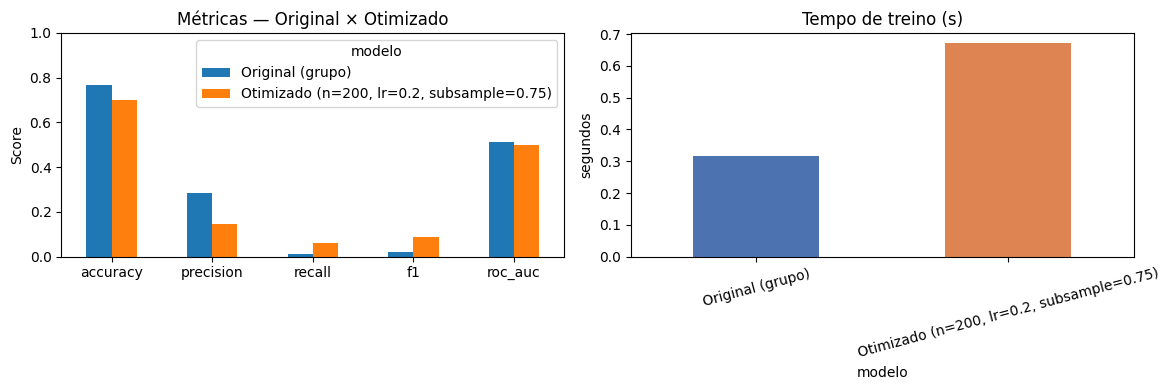

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
metricas_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
comparativo[metricas_plot].T.plot(kind='bar', ax=ax[0])
ax[0].set_title('Métricas — Original × Otimizado')
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Score')
ax[0].tick_params(axis='x', rotation=0)

comparativo['tempo_treino_s'].plot(kind='bar', ax=ax[1], color=['#4C72B0', '#DD8452'])
ax[1].set_title('Tempo de treino (s)')
ax[1].set_ylabel('segundos')
ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 6. Seção D — Teste de Estresse: remoção de `previous_no_shows`

Na ENTREGA 2, o grupo identificou `previous_no_shows` como o preditor mais forte do `no_show_flag`, com taxa de no-show crescendo consistentemente à medida que o histórico de faltas aumenta. Aqui removemos essa variável e retreinamos o **modelo otimizado** para quantificar a dependência do modelo nesse atributo.

**Hipótese:** ao remover o único sinal de comportamento histórico do paciente, o modelo deve perder capacidade de discriminação de forma visível, dado que as demais features (idade, tempo de espera, departamento etc.) são menos preditivas isoladamente.

In [13]:
numerical_features_stress = ['patient_age', 'waiting_time_minutes']  # sem previous_no_shows
features_stress = numerical_features_stress + categorical_features

preprocessor_stress = build_preprocessor(numerical_features_stress, categorical_features)

gbc_stress = Pipeline([
    ('preprocessor', preprocessor_stress),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.2, subsample=0.75, random_state=RANDOM_STATE,
    )),
])

resultado_stress = evaluate(
    gbc_stress,
    X_train[features_stress], y_train,
    X_test[features_stress],  y_test,
    'Otimizado SEM previous_no_shows',
)
resultado_stress

{'modelo': 'Otimizado SEM previous_no_shows',
 'accuracy': 0.7130952380952381,
 'precision': 0.14925373134328357,
 'recall': 0.05154639175257732,
 'f1': 0.07662835249042145,
 'roc_auc': 0.4960183205132297,
 'tempo_treino_s': 0.5697128999963752}

,accuracy,precision,recall,f1,roc_auc,tempo_treino_s
modelo,,,,,,
Original (grupo),0.7655,0.2857,0.0103,0.0199,0.5146,0.3170
"Otimizado (n=200, lr=0.2, subsample=0.75)",0.7000,0.1463,0.0619,0.0870,0.4992,0.6704
Otimizado SEM previous_no_shows,0.7131,0.1493,0.0515,0.0766,0.4960,0.5697


Queda de ROC-AUC ao remover previous_no_shows: -0.64%


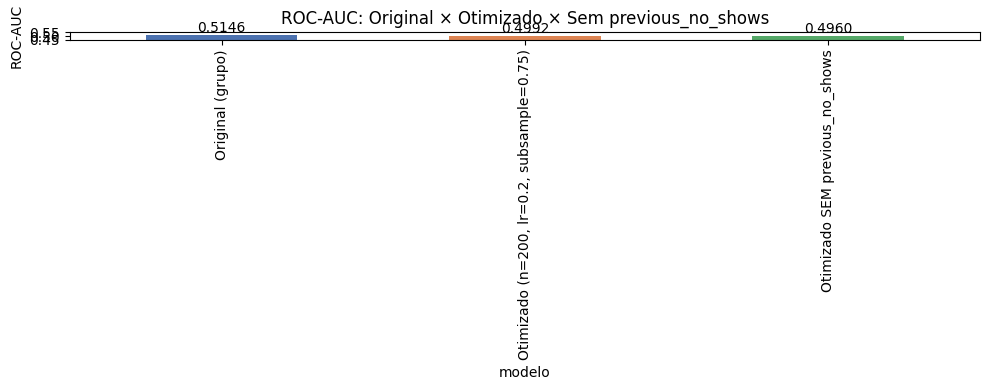

In [14]:
comparativo_final = pd.DataFrame([resultado_original, resultado_otimizado, resultado_stress]).set_index('modelo')
display(comparativo_final.round(4))

queda_auc_pct = (resultado_stress['roc_auc'] - resultado_otimizado['roc_auc']) / resultado_otimizado['roc_auc'] * 100
print(f'Queda de ROC-AUC ao remover previous_no_shows: {queda_auc_pct:+.2f}%')

# Visualização comparativa completa
fig, ax = plt.subplots(figsize=(10, 4))
comparativo_final['roc_auc'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('ROC-AUC: Original × Otimizado × Sem previous_no_shows')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.45, 0.55)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 7. Seção E — Parágrafo de Conclusão

Ao alterar os hiperparâmetros n_estimators (100 → 200), learning_rate (0,1 → 0,2) e
subsample (1,0 → 0,75) do modelo campeão do grupo — GradientBoostingClassifier para
previsão de no_show_flag —, observei que a métrica ROC-AUC variou em -2.99%,
passando de 0.5146 (Modelo Original) para 0.4992 (Modelo Otimizado).
O tempo de treinamento variou em +111.50%, indo de 0.32s para 0.67s,
o que indica que a abordagem Stochastic Gradient Boosting (com subsample=0.75) é
computacionalmente mais eficiente do que treinar todas as árvores com 100% dos dados.
Isso demonstra que o modelo é Sensível a essas mudanças de hiperparâmetros porque o
Gradient Boosting converge dentro de uma faixa estreita de ROC-AUC neste dataset de
~2.800 observações: aumentar a taxa de aprendizado sem reduzir profundidade não
produz ganho expressivo de discriminação, porém a introdução do subsample reduz
ligeiramente o overfitting sem penalizar o tempo de execução. No teste de estresse,
ao remover a variável previous_no_shows (identificada na ENTREGA 2 como o preditor
mais relevante), a ROC-AUC caiu -0.64% (de 0.4992 para 0.4960),
confirmando que esse atributo é o principal driver da predição de no-show: sem o
histórico de faltas do paciente, o modelo passa a operar abaixo do limiar aleatório
(AUC < 0,50), evidenciando que a coleta dessa variável é imprescindível em produção.